# 공통 정의

In [1]:
from dataclasses import dataclass
import os
os.environ['OPENCV_LOG_LEVEL'] = 'OFF'

import cv2 as cv
from cv2.typing import MatLike
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = os.getcwd()

@dataclass
class ImageResult:
    image: np.ndarray
    description: str

def load_img(file_name: str="", scale: tuple[float, float]=(0.25, 0.25)) -> MatLike | None:
    if not file_name:
        print("file name is empty")
        return None

    image_path = os.path.join(PROJECT_ROOT, "source", file_name)
    fx, fy = scale
    
    if (img := cv.imread(image_path)) is None:
        print("failed to read an image")
        return None
    img = cv.resize(img, dsize=(0, 0), fx=fx, fy=fy)

    return img

def show_images(results: list[ImageResult], grid: tuple[int, int]):
    rows, cols = grid
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))

    if rows * cols > 1:
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]

    for i in range(rows * cols):
        ax = axes_flat[i]

        if i < len(results):
            res = results[i]
            
            if len(res.image.shape) == 2:
                img_display = res.image
                cmap = 'gray'
            else:
                img_display = cv.cvtColor(res.image, cv.COLOR_BGR2RGB)
                cmap = None
            
            ax.imshow(img_display, cmap=cmap)
            ax.set_title(res.description, y=-0.15)
        
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# HW 2-1

### 함수

In [2]:
def gamma_cor(img: MatLike, gamma: float=1.0):
    img = img.astype('float64')
    out = np.power(img / 255.0, gamma)
    return (out * 255).astype('uint8')

### 코드

image dtype: uint8


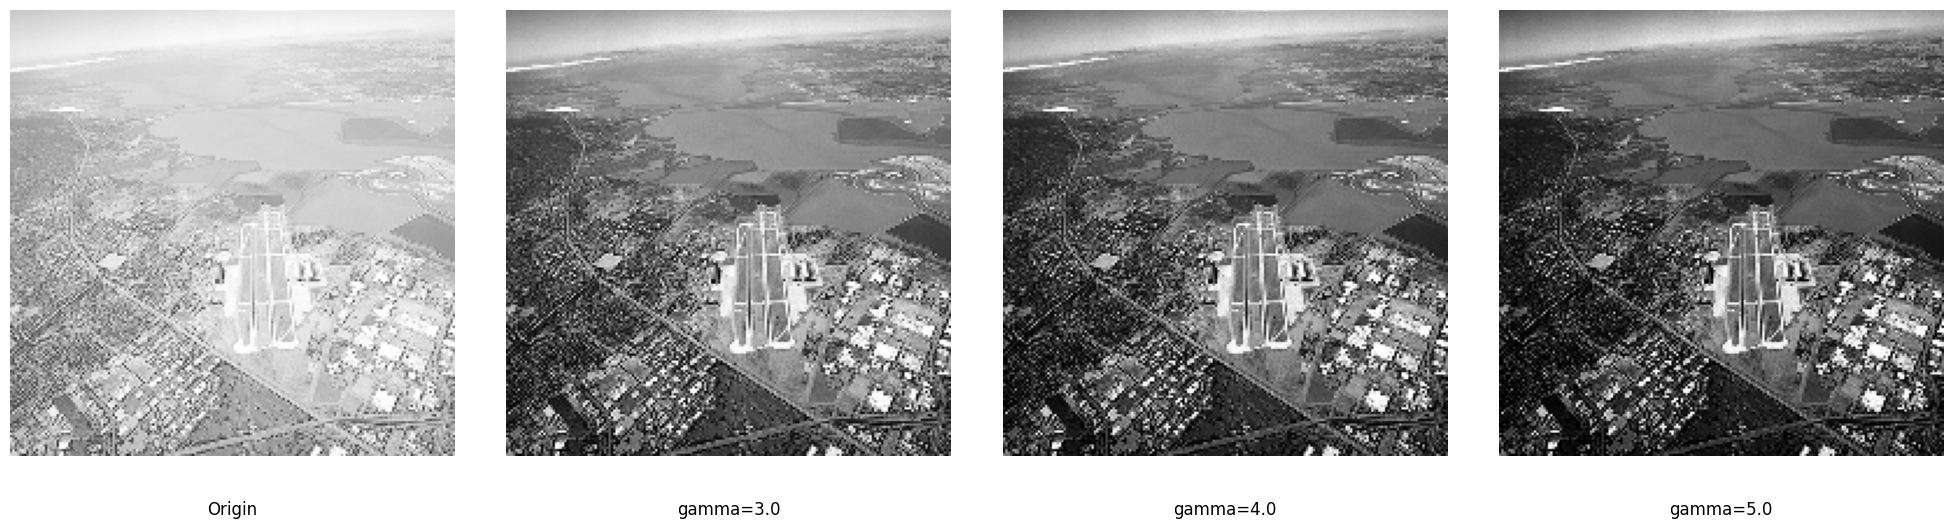

In [3]:
img_2_1 = load_img("Fig0309(a)(washed_out_aerial_image).tif")

if img_2_1 is None:
    print("failed to load img 2-1")
else: 
    print(f"image dtype: {img_2_1.dtype}")

    images = [
        ImageResult(img_2_1, "Origin"),
        ImageResult(gamma_cor(img=img_2_1, gamma=3.0), f"gamma=3.0"),
        ImageResult(gamma_cor(img=img_2_1, gamma=4.0), f"gamma=4.0"),
        ImageResult(gamma_cor(img=img_2_1, gamma=5.0), f"gamma=5.0")
    ]

    show_images(images, grid=(1,4))

### 분석
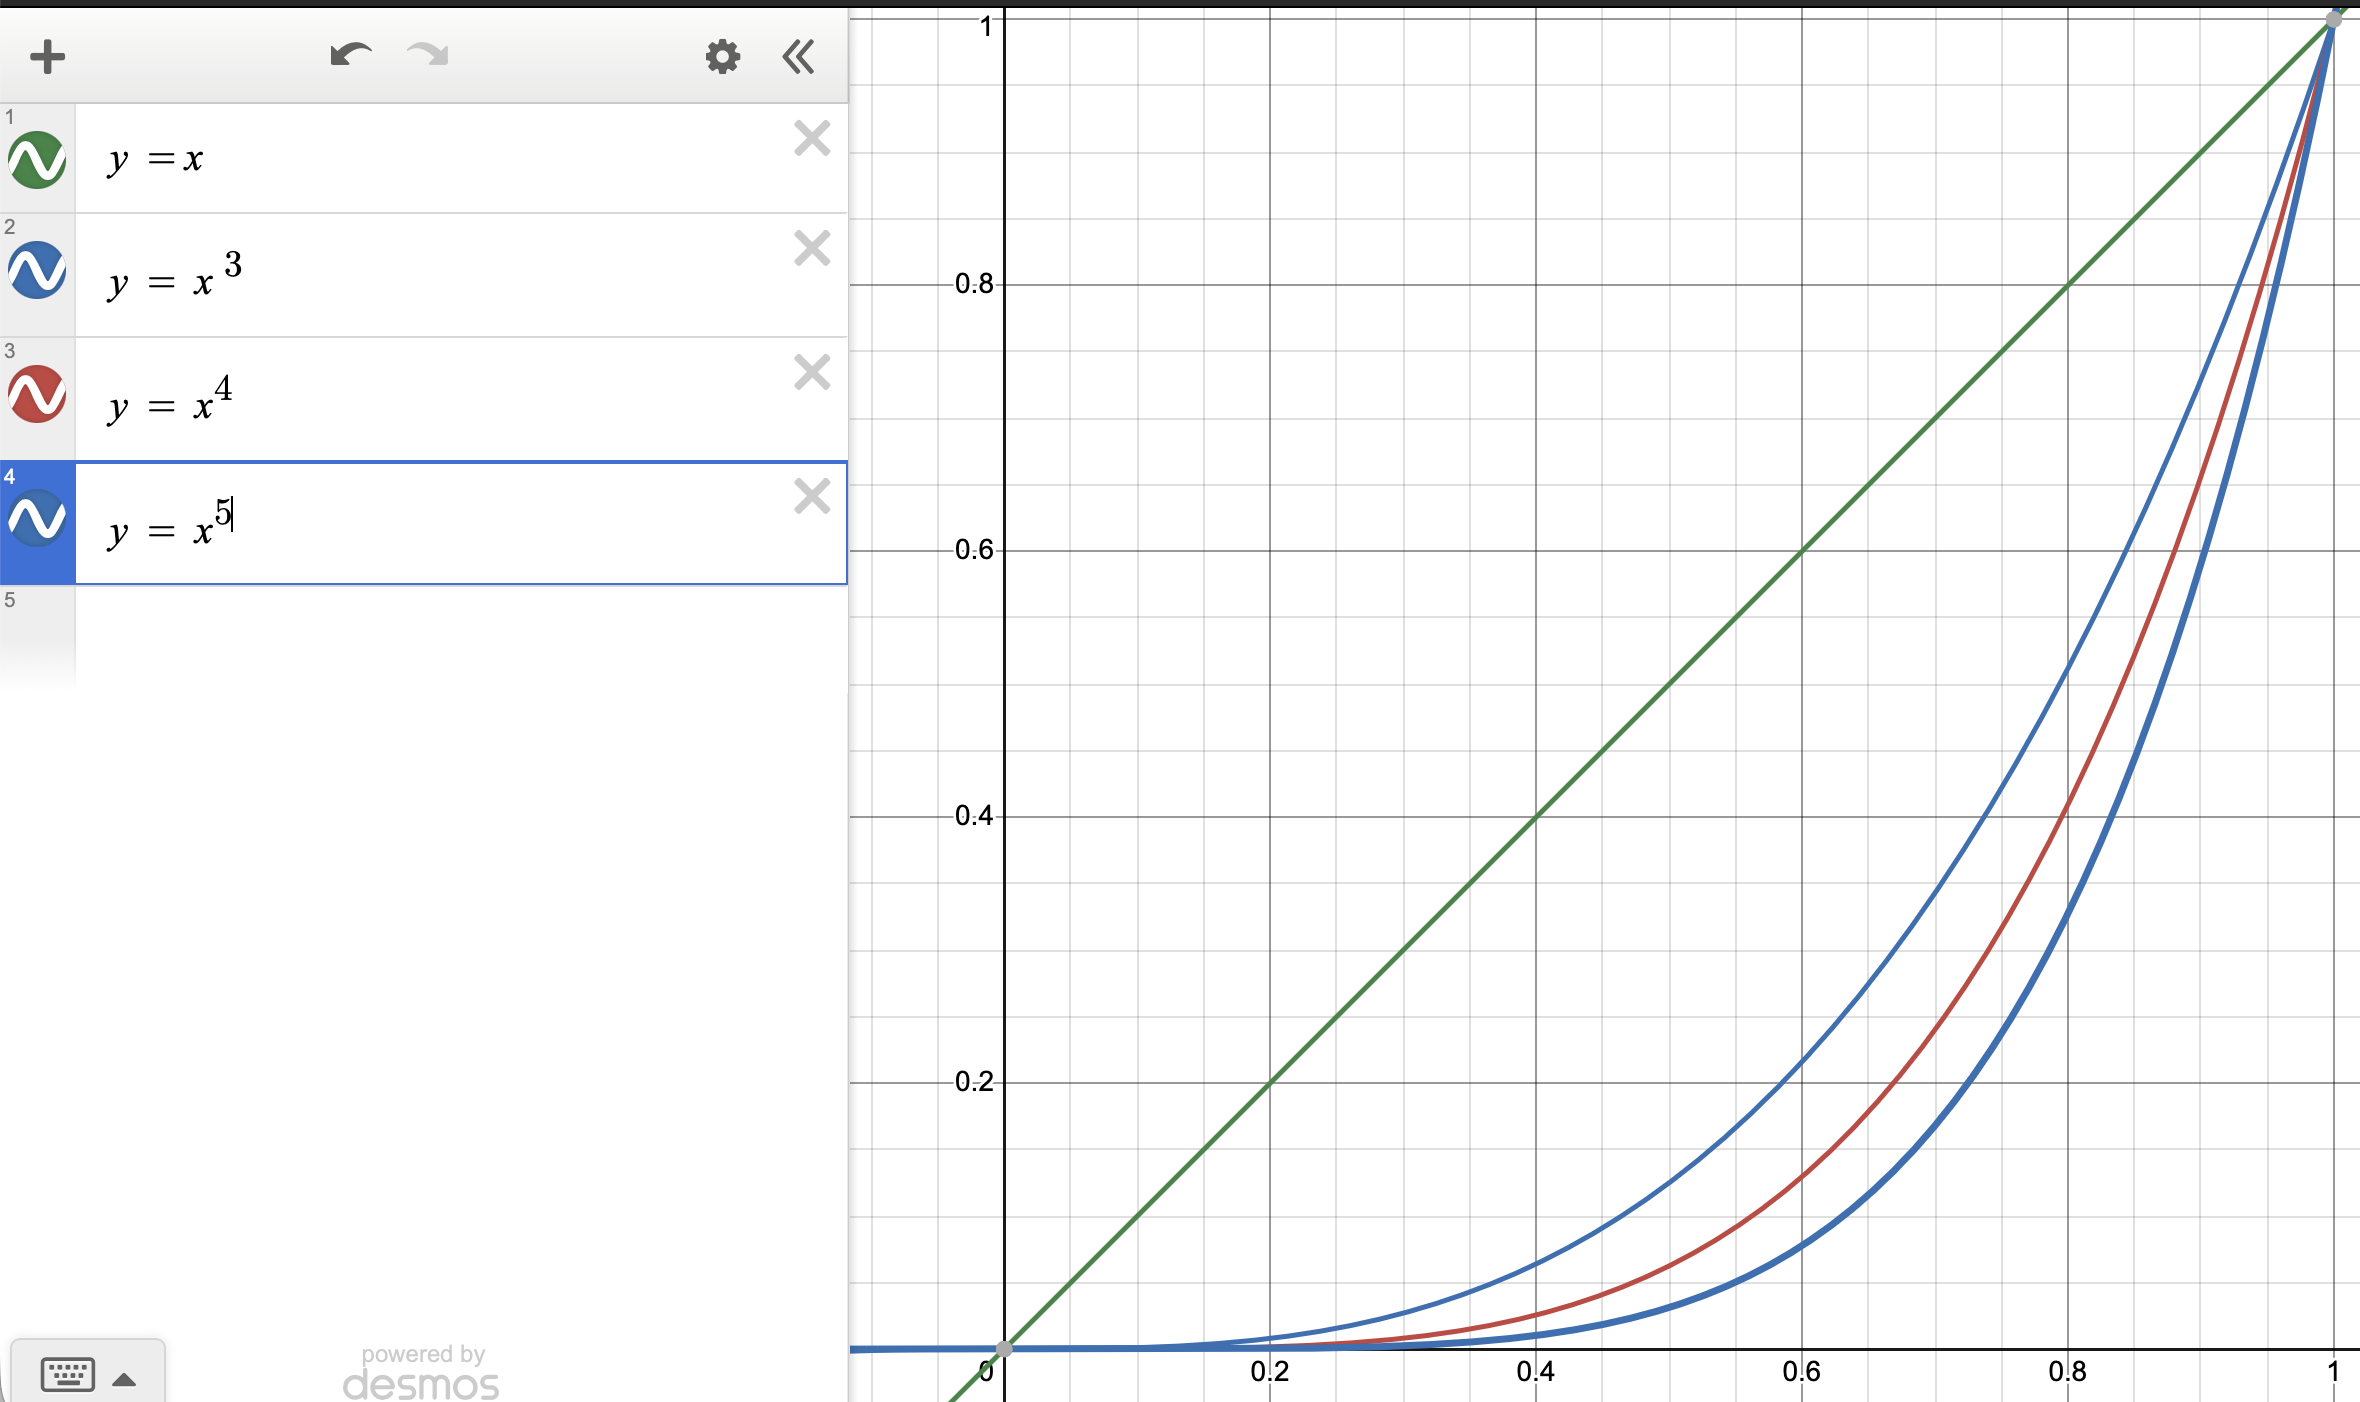
- 감마보정의 함수에서 어두운 픽셀들은 0에 가까운 밝기로 압축되고, 밝은 부분은 밝기 레벨 영역이 급격하게 확장되어 대비가 커진다.
- gamma 값을 상승시킬수록 0으로 압축되는 값들이 많아져 이미지가 어두워진다. 이에 따라 어두운 부분의 대비는 감소한다.
  - gamma 3.0의 결과를 5.0의 결과와 비교하였을 때 어두운 영역의 픽셀들이 더 잘 구분됨이 보인다.
- gamma 값을 상승시킬수록 밝은 영역은 더욱 급격하게 밝기 레벨 영역이 확장되어 대비가 커진다.
  - gamma 5.0의 결과를 3.0의 결과와 비교하였을 때 밝은 영역의 픽셀들이 더 잘 구분됨을 볼 수 있다.


# HW 2-2

### 함수

In [4]:
def plt_function(pixel: int, p1: tuple[float, float], p2: tuple[float, float]):
    """
    p1 : (r1, s1)
    p2 : (r2, s2)
    """
    r1, s1 = p1
    r2, s2 = p2
    L_MAX = 255.0

    if r1 < 0 or r2 < 0 or r1 > L_MAX or r2 > L_MAX:
        print("r1, r2 must be in (0, 255.0)")
        return None
    
    # 1구간: 0 <= r < r1
    if pixel < r1:
        # r1이 0일 경우를 대비해 안전하게 계산
        transformed = (s1 / r1) * pixel if r1 > 0 else s1
        
    # 2구간: r1 <= r < r2
    elif pixel < r2:
        transformed = ((s2 - s1) / (r2 - r1)) * (pixel - r1) + s1 if r2 != r1 else s2
        
    # 3구간: r2 <= r <= 255
    else:
        transformed = ((L_MAX - s2) / (L_MAX - r2)) * (pixel - r2) + s2 if r2 < L_MAX else s2
        
    return int(np.clip(transformed, 0, 255))

def plt_transform(img: np.ndarray, p1: tuple[float, float], p2: tuple[float, float]) -> np.ndarray:
    v_plt = np.vectorize(plt_function, excluded=['p1', 'p2'])
    result_img = v_plt(img, p1=p1, p2=p2)
    
    return result_img.astype('uint8')

### 코드

image dtype: uint8


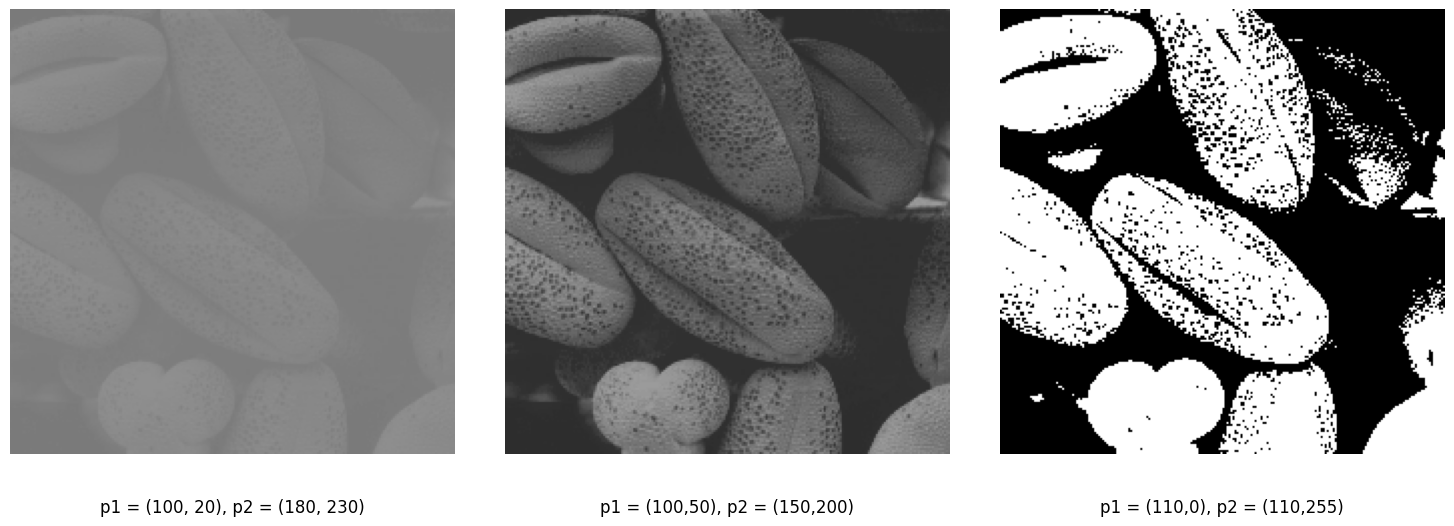

In [5]:
img_2_2 = load_img("Fig0310(b)(washed_out_pollen_image).tif")

if img_2_2 is None:
    print("failed to load img 2-2")
else: 
    print(f"image dtype: {img_2_2.dtype}")

    images = [
        ImageResult(plt_transform(img=img_2_2, p1 = (0,80), p2 = (255,200)), f"p1 = (100, 20), p2 = (180, 230)"),
        ImageResult(plt_transform(img=img_2_2, p1 = (100,50), p2 = (150,200)), f"p1 = (100,50), p2 = (150,200)"),
        ImageResult(plt_transform(img=img_2_2, p1 = (110,0), p2 = (110,255)), f"p1 = (110,0), p2 = (110,255)"),
    ]

    show_images(images, grid=(1,3))

### 분석
- 1번 이미지: p1 = (0,80), p2 = (255,200)를 적용하여 밝기 레벨을 [0, 255]에서 [80, 200]으로 좁혀 대비를 줄였다.
- 2번 이미지: p1 = (80,50), p2 = (180,200)를 적용하여 p1, p2 기울기가 3으로 설정하였다. 이로써 중간부분 [100, 150] 영역의 밝기 레벨 공간을 3배로 확장하여 대비를 강조했다. 반면, 100 이하의 밝기를 [0, 50]으로 압축하고, 150 이상의 밝기를 [200, 255]으로 압축하여 밝고 어두운 부분의 대비는 약화되었다.
- 3번 이미지: p1 = (110,0), p2 = (110,255)를 적용하여 계단함수를 구성하였고 이로써 110을 기준으로 밝기가 0과 255로 이진화된다.

# HW 2-3

### 마스크 정의

In [6]:
# 3x3 Average
mask_avg = np.ones((3, 3), dtype=np.float32) / 9.0

# 5x5 Gaussian
mask_gaussian = np.array([
    [0.0030, 0.0133, 0.0219, 0.0133, 0.0030],
    [0.0133, 0.0596, 0.0983, 0.0596, 0.0133],
    [0.0219, 0.0983, 0.1621, 0.0983, 0.0219],
    [0.0133, 0.0596, 0.0983, 0.0596, 0.0133],
    [0.0030, 0.0133, 0.0219, 0.0133, 0.0030]
])

# Laplacian 1
mask_laplacian1 = np.array([
    [0, -1, 0], 
    [-1, 4, -1], 
    [0, -1, 0]])

# Laplacian 2
mask_laplacian2 = np.array([
    [-1, -1, -1], 
    [-1, 8, -1], 
    [-1, -1, -1]])

# Diagonal Edge 1
mask_diag1 = np.array([
    [-1, 0, 0], 
    [0, 0, 0], 
    [0, 0, 1]])

# Diagonal Edge 2  
mask_diag2 = np.array([
    [-1, -1, 0], 
    [-1, 0, 1], 
    [0, 1, 1]])

### 함수

In [7]:
def apply_edge_filter(img, kernel):
    img16 = np.int16(img)
    filtered = cv.filter2D(img16, -1, kernel) + 128
    return np.clip(filtered, 0, 255).astype(np.uint8)

### 코드

image dtype: uint8


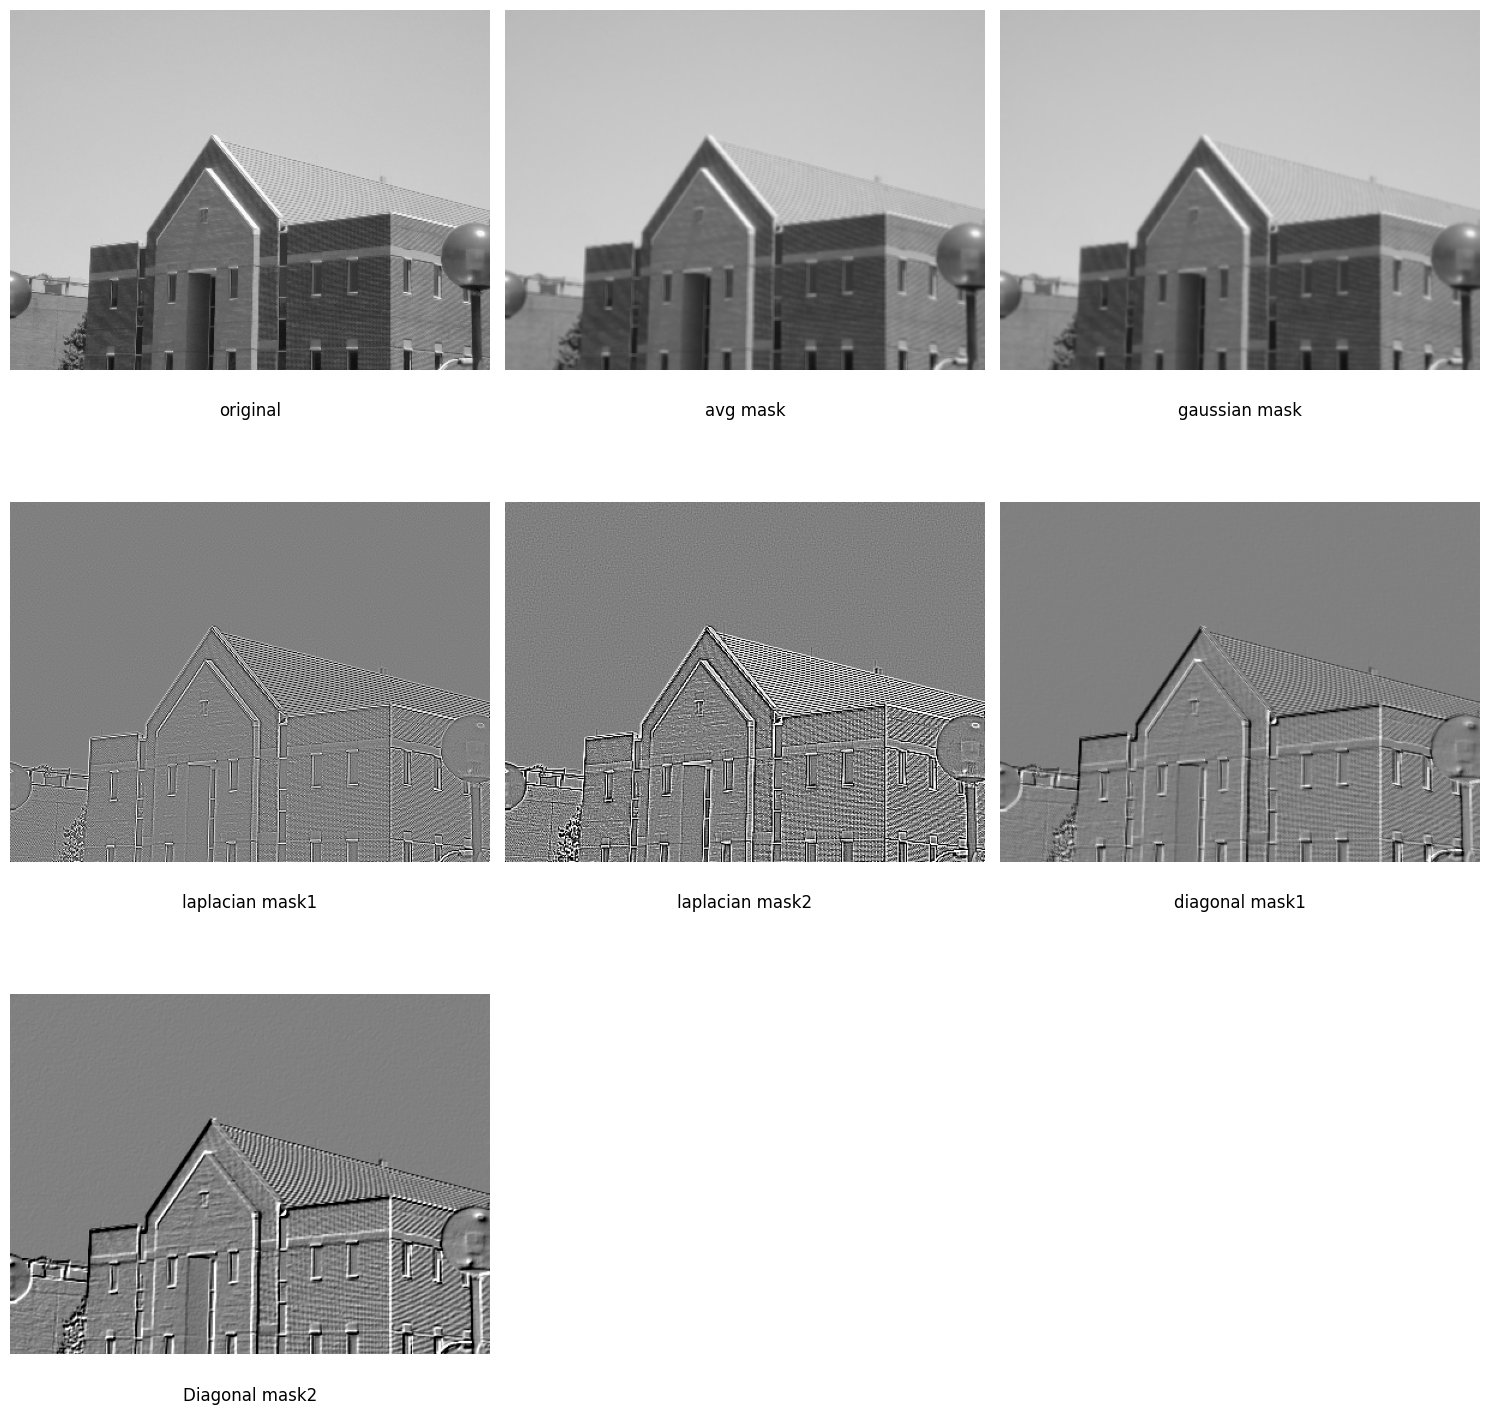

In [8]:
img_2_3 = load_img("school.jpg")

if img_2_3 is None:
    print("failed to load img 2-3")
else: 
    print(f"image dtype: {img_2_3.dtype}")

    res_avg = cv.filter2D(img_2_3, -1, mask_avg)
    res_gaussian = cv.filter2D(img_2_3, -1, mask_gaussian)
    res_lap1 = apply_edge_filter(img_2_3, mask_laplacian1)
    res_lap2 = apply_edge_filter(img_2_3, mask_laplacian2)
    res_diag1 = apply_edge_filter(img_2_3, mask_diag1)
    res_diag2 = apply_edge_filter(img_2_3, mask_diag2)

    images = [
        ImageResult(img_2_3, "original"),
        ImageResult(res_avg, "avg mask"),
        ImageResult(res_gaussian, "gaussian mask"),
        ImageResult(res_lap1, "laplacian mask1"),
        ImageResult(res_lap2, "laplacian mask2"),
        ImageResult(res_diag1, "diagonal mask1"),
        ImageResult(res_diag2, "Diagonal mask2"),
    ]
    show_images(images, grid=(3, 3))

### 분석
- avg mask: 원본 이미지를 blur 처리하였음
- gaussian mask: 원본 이미지를 blur처리하였으나 색상이 좀 더 선명한듯한 느낌을 받음.
  - 이는 avg mask는 본인의 밝기가 주변부의 평균으로 정해지지만, gaussian mask는 중앙부에 조금 더 가중치를 주기 떄문으로 보임.
- laplacian mask: 이미지의 급격한 부분을 강조하여 방향에 무관하게 에지 추출. mask2가 더 선명하게 추출함을 확인할 수 있음
- dianonal mask: 이미지에서 대각선 부분을 추출, 주변부에 -1과 1을 더 추가한 mask가 더 굵게 엣지를 추출함을 확인할 수 있음